In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 1)) & (dataset.data.index < datetime.datetime(2024, 8, 1))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 1)) & (dataset.data.index < datetime.datetime(2024, 11, 29)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
apa = systemClasses.System(dataset=dataset, name="APA")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 10.48sensor/s]


In [5]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.45sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 91.82sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  9.53sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 95.94sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.49sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 16/16 [00:00<00:00, 99.81sensor/s]


In [6]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)

# Gradient metric

The definition of a metric that defines the stability of the Valencia Temperature Gradient Monitor over time.

Processing timestamps:   0%|          | 0/41 [00:00<?, ?it/s]

Processing timestamps:  17%|█▋        | 7/41 [00:00<00:01, 29.07it/s]

Significant change detected at 2024-06-10 00:00:00, Chi2: 0.94
Significant change detected at 2024-06-10 12:00:00, Chi2: 0.78
Significant change detected at 2024-06-11 00:00:00, Chi2: 0.76


Processing timestamps: 100%|██████████| 41/41 [00:01<00:00, 29.74it/s]


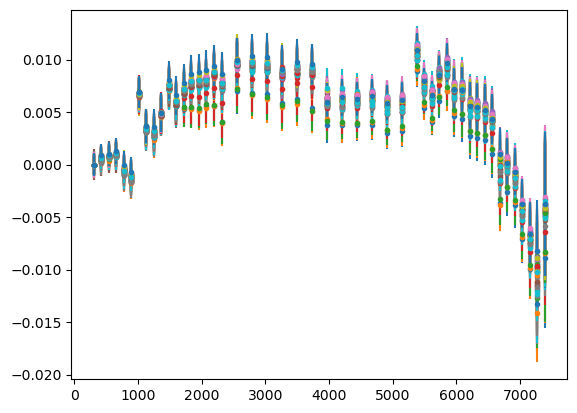

In [32]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 6, 15, 12, 0, 0), tend=datetime.datetime(2024, 6, 15, 13))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".")
ref_profile = tgrad.profiles.copy()
step = 12*60*60
timestamps = pd.date_range(start=datetime.datetime(2024, 6, 10), end=datetime.datetime(2024, 6, 30), freq=f"{step}S")
chi2_series = []
anomalies = []
chi2_threshold = 0.5 # Define a threshold for significant change
for timestamp in tqdm(timestamps, desc="Processing timestamps"):
    current_profile = tgrad.makeProfiles(tini=timestamp, tend=timestamp + datetime.timedelta(seconds=step))
    plt.errorbar(current_profile.profiles["Y"].values, current_profile.profiles["temp"].values -  current_profile.profiles["temp"].loc[(current_profile.profiles["Y"]==305)].values[0], yerr=current_profile.profiles["err"].values, fmt=".", label=f"{timestamp}")
    if len(current_profile.profiles) != len(ref_profile):
        continue
    # Combine errors from current_profile and ref_profile in quadrature
    combined_err = np.sqrt(current_profile.profiles["err"].values**2 + ref_profile["err"].values**2)
    # reduced chi2
    # Normalize both profiles to the temperature at Y==305
    y_norm = 305
    ref_temp_norm = ref_profile.loc[ref_profile["Y"] == y_norm, "temp"].values[0]
    curr_temp_norm = current_profile.profiles.loc[current_profile.profiles["Y"] == y_norm, "temp"].values[0]
    # Calculate normalized temperature arrays
    ref_temp_normed = ref_profile["temp"].values - ref_temp_norm
    curr_temp_normed = current_profile.profiles["temp"].values - curr_temp_norm
    # Compute reduced chi2 between normalized profiles
    chi2 = np.sum(((curr_temp_normed - ref_temp_normed) / combined_err) ** 2) / (len(curr_temp_normed) - 1)
    chi2_series.append((timestamp, chi2))
    if chi2 > chi2_threshold:
        print(f"Significant change detected at {timestamp}, Chi2: {chi2:.2f}")
        anomalies.append((timestamp, current_profile.profiles.copy()))

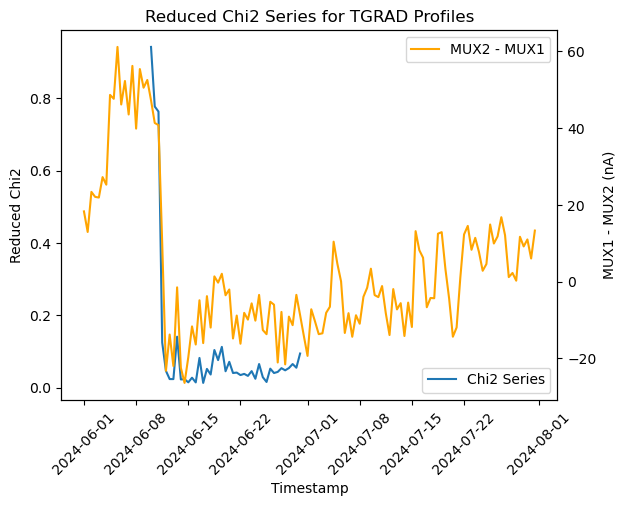

In [33]:
fig, axes = plt.subplots(1,1)
df_chi2 = pd.DataFrame(chi2_series, columns=["timestamp", "chi2"])
df_chi2 = df_chi2.set_index("timestamp")
axes.plot(df_chi2.index.values, df_chi2["chi2"].values, label="Chi2 Series")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Timestamp")
axes.set_ylabel("Reduced Chi2")
axes.set_title("Reduced Chi2 Series for TGRAD Profiles")
axes2 = axes.twinx()
axes2.plot(mux1.data.loc[(mux1.data.index<datetime.datetime(2024, 8, 1))].resample("12h").mean().index.values,
           -1e6*(mux1.data.loc[(mux1.data.index<datetime.datetime(2024, 8, 1))].resample("12h").mean() - mux2.data.loc[(mux1.data.index<datetime.datetime(2024, 8, 1))].resample("12h").mean()).values,
           label="MUX2 - MUX1", color="orange")
# axes2.set_ylim(-100, 100)
axes2.set_ylabel("MUX1 - MUX2 (nA)")
axes2.legend(loc="upper right")
axes.legend(loc="lower right")

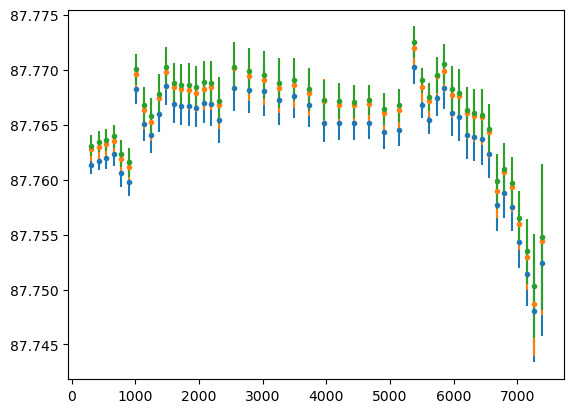

In [34]:
for timestamp, profile in anomalies:
    plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt=".", label=f"{timestamp}")
# plt.legend()
plt.show()

In [35]:
timestamps = pd.date_range(start="2024-11-20 12:00:00", end="2024-11-29 12:00:00", freq="D")
print(timestamps)

DatetimeIndex(['2024-11-20 12:00:00', '2024-11-21 12:00:00',
               '2024-11-22 12:00:00', '2024-11-23 12:00:00',
               '2024-11-24 12:00:00', '2024-11-25 12:00:00',
               '2024-11-26 12:00:00', '2024-11-27 12:00:00',
               '2024-11-28 12:00:00', '2024-11-29 12:00:00'],
              dtype='datetime64[ns]', freq='D')


2024-11-20 12:00:00 2024-11-20 12:01:00 2024-11-20 13:00:00


KeyError: 'Y'

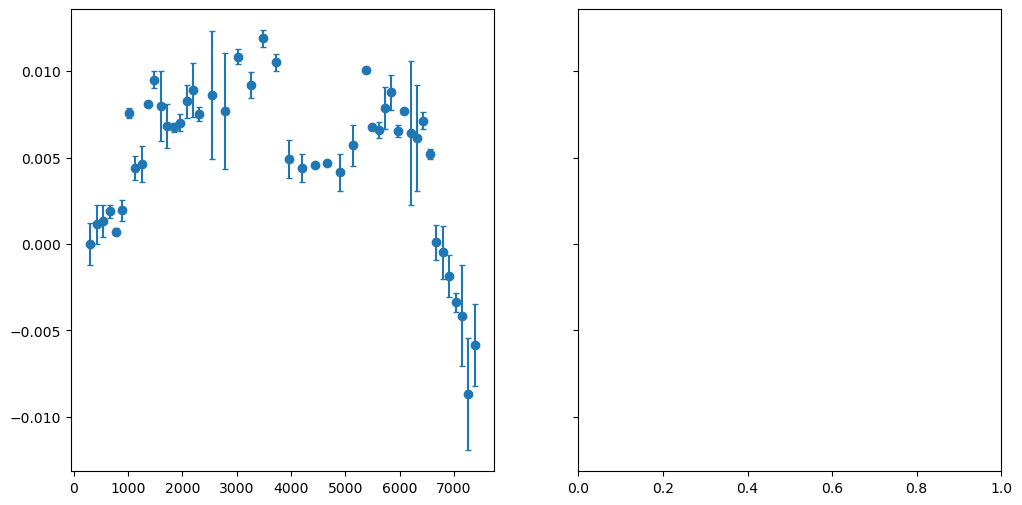

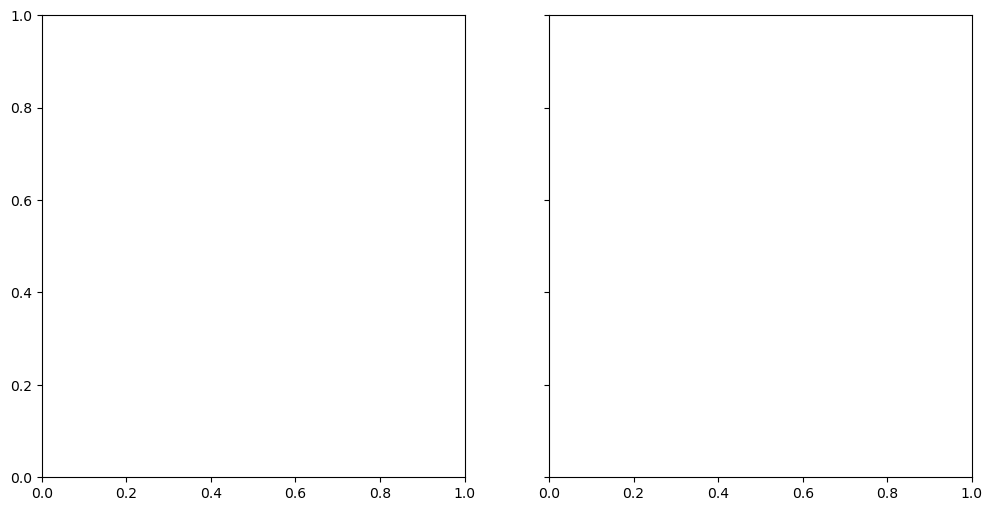

In [37]:
profiles_list = []

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for tini in timestamps:
    tend_short = tini + datetime.timedelta(minutes=1)
    tend_long = tini + datetime.timedelta(minutes=60)
    print(tini, tend_short, tend_long)
    ##############################################################################
    tgrad.makeProfiles(tini=tini, tend=tend_short)
    hawai.makeProfiles(tini=tini, tend=tend_short)
    # Create a temporary profile DataFrame for the short duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # Add a column for timestamp and duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # profiles_list.append(temp_profile_short)
    axes[0].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[0].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==1107)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################
    # Create a temporary profile DataFrame for the long duration
    tgrad.makeProfiles(tini=tini, tend=tend_long)
    hawai.makeProfiles(tini=tini, tend=tend_long)
    # Create a temporary profile DataFrame for the long duration
    temp_profile_long = hawai.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    # Add a column for timestamp and duration
    temp_profile_long = tgrad.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    profiles_list.append(temp_profile_long)
    axes[1].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[1].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==1107)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################

# Merge all profiles into a single DataFrame
# Merge all profiles in profiles_list on the 'Y' column, keeping only rows with matching 'Y' values
merged_profiles = profiles_list[0][["Y"]].copy()
for i, df in enumerate(profiles_list):
    merged_profiles = merged_profiles.merge(
        df[["Y", "temp"]].rename(columns={"temp": f"temp_{i}"}),
        on="Y",
        how="inner"
    )
axes[0].legend(ncol=2)
axes[1].legend(ncol=2)
axes[0].set_title("Calculated over 1 minute")
axes[1].set_title("Calculated over 60 minutes")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_xlabel("Y [m]")
axes[1].set_xlabel("Y [m]")
fig.tight_layout()

axes2[0].legend(ncol=2)
axes2[1].legend(ncol=2)
axes2[0].set_title("Calculated over 1 minute")
axes2[1].set_title("Calculated over 60 minutes")
axes2[0].set_ylabel("Temperature [K]")
axes2[0].set_xlabel("Y [m]")
axes2[1].set_xlabel("Y [m]")
fig2.tight_layout()

In [68]:
merged_profiles = merged_profiles.set_index("Y")
merged_temps = merged_profiles.mean(axis=1)
merged_errors = merged_profiles.std(axis=1)

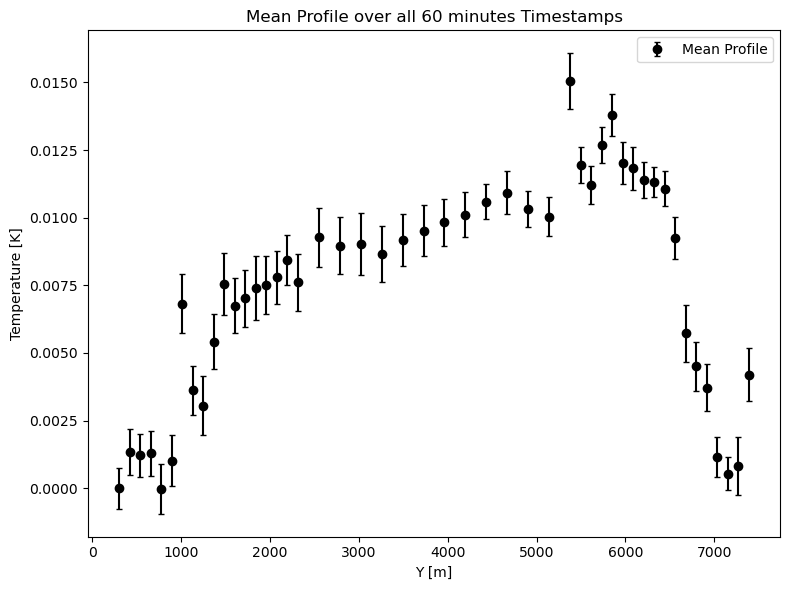

In [80]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
axes.errorbar(
    merged_profiles.index.values,
    (merged_temps - merged_temps.loc[305]).values,
    yerr=merged_errors,
    fmt='o',
    label='Mean Profile',
    color='black',
    capsize=2.5)
axes.set_title("Mean Profile over all 60 minutes Timestamps")
axes.set_ylabel("Temperature [K]")
axes.set_xlabel("Y [m]")
axes.legend()
fig.tight_layout()

In [23]:
timestamps = pd.date_range(start="2024-5-5 12:00:00", end="2024-5-14 12:00:00", freq="D")
print(timestamps)

DatetimeIndex(['2024-05-05 12:00:00', '2024-05-06 12:00:00',
               '2024-05-07 12:00:00', '2024-05-08 12:00:00',
               '2024-05-09 12:00:00', '2024-05-10 12:00:00',
               '2024-05-11 12:00:00', '2024-05-12 12:00:00',
               '2024-05-13 12:00:00', '2024-05-14 12:00:00'],
              dtype='datetime64[ns]', freq='D')


2024-05-05 12:00:00 2024-05-05 12:01:00 2024-05-05 13:00:00
2024-05-06 12:00:00 2024-05-06 12:01:00 2024-05-06 13:00:00
2024-05-07 12:00:00 2024-05-07 12:01:00 2024-05-07 13:00:00
2024-05-08 12:00:00 2024-05-08 12:01:00 2024-05-08 13:00:00
2024-05-09 12:00:00 2024-05-09 12:01:00 2024-05-09 13:00:00
2024-05-10 12:00:00 2024-05-10 12:01:00 2024-05-10 13:00:00
2024-05-11 12:00:00 2024-05-11 12:01:00 2024-05-11 13:00:00
2024-05-12 12:00:00 2024-05-12 12:01:00 2024-05-12 13:00:00
2024-05-13 12:00:00 2024-05-13 12:01:00 2024-05-13 13:00:00
2024-05-14 12:00:00 2024-05-14 12:01:00 2024-05-14 13:00:00


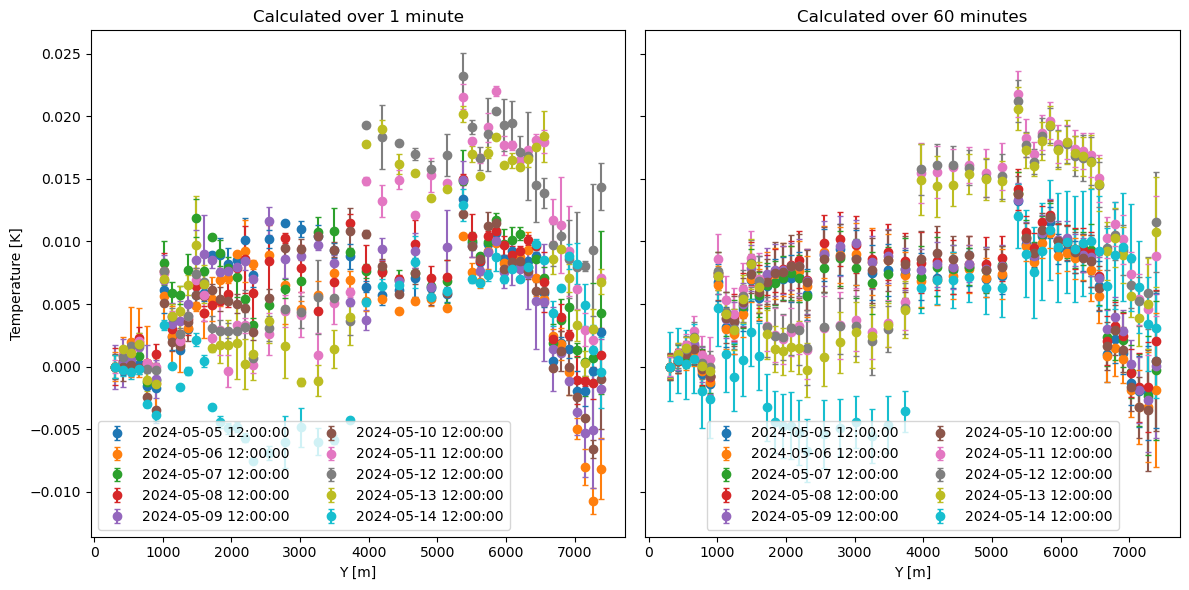

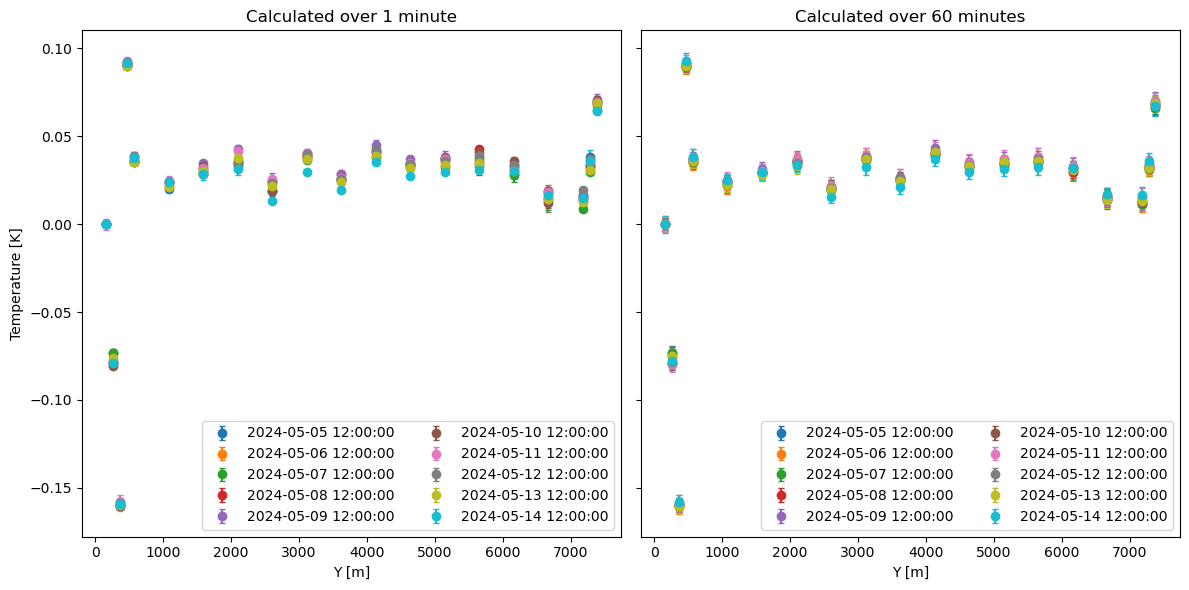

In [25]:
profiles_list = []
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for tini in timestamps:
    tend_short = tini + datetime.timedelta(minutes=1)
    tend_long = tini + datetime.timedelta(minutes=60)
    print(tini, tend_short, tend_long)
    ##############################################################################
    tgrad.makeProfiles(tini=tini, tend=tend_short)
    hawai.makeProfiles(tini=tini, tend=tend_short)
    # Create a temporary profile DataFrame for the short duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # Add a column for timestamp and duration
    temp_profile_short = tgrad.profiles.copy()
    temp_profile_short["timestamp"] = tini
    temp_profile_short["duration_min"] = 1
    # profiles_list.append(temp_profile_short)
    axes[0].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[0].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==165)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################
    # Create a temporary profile DataFrame for the long duration
    tgrad.makeProfiles(tini=tini, tend=tend_long)
    hawai.makeProfiles(tini=tini, tend=tend_long)
    # Create a temporary profile DataFrame for the long duration
    temp_profile_long = hawai.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    # Add a column for timestamp and duration
    temp_profile_long = tgrad.profiles.copy()
    temp_profile_long["timestamp"] = tini
    temp_profile_long["duration_min"] = 60
    profiles_list.append(temp_profile_long)
    axes[1].errorbar(
        tgrad.profiles["Y"].values,
        tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
        yerr=tgrad.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    axes2[1].errorbar(
        hawai.profiles["Y"].values,
        hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"]==165)].values[0],
        yerr=hawai.profiles["err"].values,
        fmt='o', capsize=2.5,
        label=f'{tini.strftime("%Y-%m-%d %H:%M:%S")}'
    )
    ##############################################################################

# Merge all profiles into a single DataFrame
# Merge all profiles in profiles_list on the 'Y' column, keeping only rows with matching 'Y' values
merged_profiles = profiles_list[0][["Y"]].copy()
for i, df in enumerate(profiles_list):
    merged_profiles = merged_profiles.merge(
        df[["Y", "temp"]].rename(columns={"temp": f"temp_{i}"}),
        on="Y",
        how="inner"
    )
axes[0].legend(ncol=2)
axes[1].legend(ncol=2)
axes[0].set_title("Calculated over 1 minute")
axes[1].set_title("Calculated over 60 minutes")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_xlabel("Y [m]")
axes[1].set_xlabel("Y [m]")
fig.tight_layout()

axes2[0].legend(ncol=2)
axes2[1].legend(ncol=2)
axes2[0].set_title("Calculated over 1 minute")
axes2[1].set_title("Calculated over 60 minutes")
axes2[0].set_ylabel("Temperature [K]")
axes2[0].set_xlabel("Y [m]")
axes2[1].set_xlabel("Y [m]")
fig2.tight_layout()